
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eldanc/mlbootcamp2026/blob/main/lab_4_1_words.ipynb)

# UofT FASE ML Bootcamp
#### Thursday June 11, 2026
####  Word Embeddings - Properties, Meaning and Training - Lab 1, Day 4
#### Teaching team: Eldan Cohen, Alex Olson, Hriday Chheda
##### Lab author: Nakul Upadhya (Based on CARTE-DSI ML Bootcamp 2023 notebook by Prof. Jonathan Rose)

This lab engages you in the properties, meaning, viewing and training of word embeddings (also called word vectors). The specific learning objectives in this assignment are:

1.   To learn word embedding properties, and use them in simple ways.
2.   (optional) To translate vectors into understandable categories of meaning
3.   To understand how embeddings are created, using the Skip Gram method.

---





# Experimenting and Understanding Word Embedding/Vectors


Word embeddings (also known as word vectors) are a way to encode the meaning of words into a set of numbers.

These embeddings are created by training a neural network model using many examples of the use of language.  These examples could be the whole of Wikipedia or a large collection of news articles.

To start, we will explore a set of word embeddings that someone else took the time and computational power to create. One of the most commonly-used pre-trained word embeddings are the **GloVe embeddings**.

## GloVe Embeddings

You can read about the GloVe embeddings here: https://nlp.stanford.edu/projects/glove/, and read the original paper describing how they work here: https://nlp.stanford.edu/pubs/glove.pdf.

There are several variations of GloVe embeddings. They differ in the text used to train the embedding, and the *size* of the embeddings.

Throughout this lab we'll use a package called `staticvectors`, a package for obtaining pre-trained static word embeddings that is part of the `huggingface` model family.

We'll begin by loading a set of GloVe embeddings. The first time you run the code below, it will cause the download of a large file (862MB) containing the embeddings.

In [1]:
# Import the required libraries
!pip install huggingface staticvectors
import torch
from staticvectors import StaticVectors
import pandas as pd
import numpy as np

In [2]:
glove = StaticVectors('neuml/glove-6B')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/149 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/480M [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/7.69M [00:00<?, ?B/s]

We can use the loaded glove embeddings to look up the embeddings of individual words.
For example, let's look at what the embedding of the word "apple" looks like:

In [3]:
print("Embedding Shape:", glove.embeddings('apple').shape)
print(glove.embeddings('apple'))

Embedding Shape: (300,)
[-0.02940375 -0.00277475  0.0090264  -0.10073487 -0.02988201 -0.08363605
 -0.02160771  0.0062381   0.08928768 -0.11966488 -0.02980865 -0.0278815
  0.02684598 -0.07932325  0.03826917  0.03355148 -0.07320605 -0.03458982
  0.00497206  0.01366113  0.03512593  0.10055993  0.00540037 -0.01483308
 -0.0674218  -0.05574749 -0.03836511 -0.06267872  0.00862418 -0.03270219
 -0.05064889 -0.02573146  0.0050093  -0.01237534 -0.15259138 -0.05998833
  0.00045484 -0.06488378 -0.00613159 -0.05506466  0.07322016  0.02982276
 -0.03601332  0.16654412 -0.02686291 -0.0171496   0.00482294 -0.0087915
  0.02034505 -0.07528839  0.06690686 -0.06307656  0.08189231  0.06147954
  0.01863658 -0.01350298 -0.05245611 -0.00195211  0.02906375 -0.0142476
  0.01507432 -0.04757617  0.01549897  0.04908996 -0.01408522  0.05211752
 -0.07465494  0.01750371 -0.06507565 -0.05429155 -0.01426876 -0.02487793
  0.05300914  0.02310456 -0.03100923 -0.0378671   0.11950264 -0.05025104
 -0.01184953 -0.02860524 -0.07

As we can see from the output above, the embedding of a given word is a numpy array with dimension `(50,)`. We don't know what the meaning of each number is, but we do know that there are properties of the embeddings that can be observed. For example, `distances between embeddings` are meaningful.

## Measuring Distance

Let's consider one specific metric of distance between two embedding vectors called the **Euclidean distance**. The Euclidean distance of two vectors $x = [x_1, x_2, ... x_n]$ and
$y = [y_1, y_2, ... y_n]$ is just the 2-norm of their difference $x - y$. We can compute
the Euclidean distance between $x$ and $y$: $\sqrt{\sum_i (x_i - y_i)^2}$


Here we define a function to calculate the norm between two vectors:


In [4]:
def word_euclidean_distance(x, y):
  a = glove.embeddings(x) # get embeddings
  b = glove.embeddings(y)
  return np.linalg.norm(a-b) # use np.linalg to calculate the norm

Now lets use this function to get distances between words:

In [5]:
word_euclidean_distance('apple', 'banana')

np.float32(1.1023837)

In [6]:
word_euclidean_distance('good', 'bad')

np.float32(0.8431821)

In [7]:
word_euclidean_distance('good', 'water')

np.float32(1.1512811)

In [8]:
word_euclidean_distance('good', 'well')

np.float32(0.76867276)

In [9]:
word_euclidean_distance('good', 'perfect')

np.float32(0.90633327)

## Cosine Similarity

An alternative and more commonly-used measure of distance is the **Cosine Similarity**. The cosine similarity measures the *angle* between two vectors, and has the property that it only considers the *direction* of the vectors, not their the magnitudes. It is computed as follows for two vectors A and B:


![picture](https://drive.google.com/uc?id=1hSaQRBjH828lx1xozJCA4F0ZhiX2S0Xt)

Lets create a new function to measure the cosine similarity between two words:


In [10]:
def word_cosine_distance(x, y):
  a = glove.embeddings(x) # get embeddings
  b = glove.embeddings(y)
  norm_a = np.linalg.norm(a)
  norm_b = np.linalg.norm(b)
  return np.dot(a, b) / (norm_a * norm_b)

The cosine similarity is actually a *similarity* measure rather than a *distance* measure, and gives a result between -1 and 1. Thus, the larger the similarity, (closer to 1) the "closer in meaning" the word embeddings are to each other.

In [11]:
word_cosine_distance('cat', 'dog')

np.float32(0.6816747)

In [12]:
word_cosine_distance('good', 'bad')

np.float32(0.644522)

In [13]:
word_cosine_distance('good', 'water')

np.float32(0.33727583)

In [14]:
word_cosine_distance('good', 'perfect')

np.float32(0.58928007)

In [15]:
word_cosine_distance('watermelon', 'airplane')

np.float32(-0.024662025)

## Word Similarity

Now that we have notions of distance and similarity in our embedding space, we can talk about words that are "close" to each other in the embedding space. For now, let's use Euclidean distances to look at how close various words are to the word "cat".

In [16]:
word = 'cat'
other = ['pet', 'dog', 'bike', 'kitten', 'puppy', 'kite', 'computer', 'neuron']
for w in other:
    dist = word_euclidean_distance(word, w)
    print(w, "\t%5.2f" % float(dist))

pet 	 0.91
dog 	 0.80
bike 	 1.29
kitten 	 1.07
puppy 	 1.08
kite 	 1.22
computer 	 1.26
neuron 	 1.41


Let's do the same thing with cosine similarity:

In [17]:
word = 'cat'
other = ['pet', 'dog', 'bike', 'kitten', 'puppy', 'kite', 'computer', 'neuron']
for w in other:
    dist = word_cosine_distance(word, w)
    print(w, "\t%5.2f" % float(dist))

pet 	 0.59
dog 	 0.68
bike 	 0.17
kitten 	 0.43
puppy 	 0.42
kite 	 0.25
computer 	 0.20
neuron 	 0.00


We can look through the entire **vocabulary** for words that are closest to a point in the embedding space -- for example, we can look for words that are closest to another word such as "cat".

In [18]:
def print_closest_words(glove_vector, n=5):
  tokens = glove.tokens
  distances = [None] * len(tokens)
  for i, token in enumerate(tokens):
      distance = np.linalg.norm(glove.embeddings(token) - glove_vector)
      distances[i] = {
          'token': token,
          'distance': distance
      }
  sorted_distances = sorted(distances, key=lambda x: x['distance'])
  df = pd.DataFrame(sorted_distances[1:n+1]) # ignore the word itself
  return df


In [19]:
print_closest_words(glove.embeddings("cat"), n=10)

,token,distance
0,dog,0.797904
1,cats,0.798018
2,pet,0.908805
3,dogs,0.958367
4,feline,1.010151
5,monkey,1.011985
6,horse,1.026437
7,pets,1.035871
8,rabbit,1.038387
9,leopard,1.040628


In [20]:
print_closest_words(glove.embeddings("dog"), n=10)

,token,distance
0,dogs,0.649837
1,cat,0.797904
2,pet,0.861209
3,puppy,0.901547
4,hound,0.952028
5,horse,0.962315
6,animal,0.967838
7,cats,0.991893
8,canine,0.996149
9,pets,0.998001


In [21]:
print_closest_words(glove.embeddings("doctor"), n=10)

,token,distance
0,physician,0.769305
1,doctors,0.835807
2,medical,0.895405
3,dr.,0.895997
4,surgeon,0.905819
5,nurse,0.909965
6,hospital,0.929173
7,dentist,0.942188
8,patient,0.942236
9,pharmacist,0.965623


---

**Your Turn**

Try searching for similar words for words of your choice here:


In [24]:
#You can also try printing closest words to any other words of your choice here:
print_closest_words(glove.embeddings("computer"), n=10)

,token,distance
0,computers,0.591920
1,software,0.730148
2,pc,0.867163
3,technology,0.871947
4,computing,0.874212
5,laptop,0.899388
6,internet,0.910189
7,ibm,0.913748
8,systems,0.922497
9,hardware,0.924252


In [25]:
print_closest_words(glove.embeddings("air"), n=10)

,token,distance
0,force,0.870707
1,aircraft,0.917559
2,jet,0.944709
3,flight,0.950447
4,planes,0.950784
5,aviation,0.962216
6,pilots,0.964190
7,flying,0.984827
8,flights,0.989916
9,pilot,0.992837


In [26]:
print_closest_words(glove.embeddings("sports"), n=10)

,token,distance
0,sport,0.738379
1,sporting,0.916363
2,basketball,0.917791
3,soccer,0.923703
4,baseball,0.941091
5,football,0.942744
6,espn,0.988950
7,athletics,0.992889
8,athletic,0.992972
9,entertainment,0.993770


---


We could also look at which words are closest to the midpoints of two words:

In [27]:
print_closest_words((glove.embeddings('happy') + glove.embeddings('sad')) / 2)

,token,distance
0,sad,0.466216
1,sorry,0.777559
2,'m,0.779113
3,glad,0.785744
4,feel,0.807569


In [28]:
print_closest_words((glove.embeddings('doctor') + glove.embeddings('engineer')) / 2)


,token,distance
0,engineer,0.589155
1,physician,0.765541
2,surgeon,0.824165
3,technician,0.827089
4,scientist,0.842185


## 1.2 Analogies

One surprising aspect of word embeddings is that the *directions* in the embedding space can be meaningful. For example, some analogy-like relationships like this tend to hold:

$$ king - man + woman \approx queen $$

Analogies show us how relationships between pairs of words that is captured in the learned vectors

In [29]:
print_closest_words(glove.embeddings('king') - glove.embeddings('man') + glove.embeddings('woman'))

,token,distance
0,queen,0.895571
1,princess,1.050122
2,throne,1.055310
3,monarch,1.059588
4,daughter,1.099535


The top result is a reasonable answer like "queen", and the other results include words like "princess."

We can also do the reverse!

In [30]:
print_closest_words(glove.embeddings('queen') - glove.embeddings('woman') + glove.embeddings('man'))

,token,distance
0,king,0.895571
1,ii,1.069314
2,prince,1.083636
3,majesty,1.086140
4,monarch,1.097324


In [31]:
print_closest_words(glove.embeddings('king') - glove.embeddings('prince') + glove.embeddings('princess'))

,token,distance
0,princess,0.872167
1,queen,0.885374
2,elizabeth,1.123614
3,diana,1.126782
4,mother,1.128897


---

**Your Turn**

Consider now the word pair relationships given in Figure 1 below, which comes from Table 1 of the Mikolov [[link](https://arxiv.org/abs/1301.3781)] paper. Choose one of these relationships, but not one of the ones already shown above, and report which one you chose. Write and run code that will generate the second word given the first word. Generate 10 more examples of the same relationship from 10 other words, and comment on the quality of the results.

![picture](https://drive.google.com/uc?id=1O7Zizu63jj5aoZkGkK0sz93CZSEsBDuW)



In [32]:
# TODO
# Choose one of the relationships from the table above and generate 10 examples

# Plural noun relationship
print_closest_words(glove.embeddings('dollars') - glove.embeddings('dollar') + glove.embeddings('cat'))


,token,distance
0,pet,1.133481
1,cats,1.135303
2,dog,1.162009
3,dogs,1.235054
4,rat,1.262925


In [37]:
# Common Capital city relationship
print_closest_words(glove.embeddings('greece') - glove.embeddings('athens') + glove.embeddings('oslo'))

,token,distance
0,norway,0.865854
1,norwegian,1.054101
2,denmark,1.070417
3,accords,1.070994
4,iceland,1.107765


---

# 3. Training A Word Embedding Using the Skip-Gram Method on a Small Corpus

So far in this notebook we've used the pre-trained GloVe embeddings. The lecture this morning described the Skip Gram method of training word embeddings. In this section you are going to review code to use that method to train a very small embedding, for a very small vocabulary on a very small corpus of text. The goal is to gain some insight into the general notion of how embeddings are produced. The corpus you are going to use is in the file SmallSimpleCorpus.txt, and was also shown in the lecture.

In [38]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import spacy

In [39]:
# Load SpaCy's English language model
nlp = spacy.load("en_core_web_sm")

First, we read the file SmallSimpleCorpus.txt into our notebook and do some pre-processing to make the learning easier later. Specifically, we lemmatize the corpus,
which means converting words to their root - for example the word “holds” becomes “hold”, whereas the word  “hold” itself stays the same.
The `prepare_texts` function performs lemmatization using the [spaCy](https://spacy.io/models/en) library.

In [40]:
!wget https://raw.githubusercontent.com/eldanc/mlbootcamp2025/refs/heads/main/SmallSimpleCorpus.txt

with open('./SmallSimpleCorpus.txt', 'r') as file:
    corpus = file.read()
corpus

--2026-06-12 14:29:38--  https://raw.githubusercontent.com/eldanc/mlbootcamp2025/refs/heads/main/SmallSimpleCorpus.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5173 (5.1K) [text/plain]
Saving to: ‘SmallSimpleCorpus.txt’

SmallSimpleCorpus.t 100%[===================>]   5.05K  --.-KB/s    in 0s      

2026-06-12 14:29:38 (38.2 MB/s) - ‘SmallSimpleCorpus.txt’ saved [5173/5173]



'I hold a dog.  I hold the dog.  I hold a cat.  I hold the cat.  I rub a dog.  I rub the dog.  I rub a cat.  I rub the cat.  I hold and rub a dog.  I hold and rub the dog.  I hold and rub a cat.  I hold and rub the cat.  I hold a dog and cat.  I hold the dog and cat.  I hold a cat and dog.  I hold the cat and dog.  I rub a dog and cat.  I rub the dog and cat.  I rub a cat and dog.  I rub the cat and dog.  I hold and rub a dog .  I hold and rub a cat.  I hold and rub the dog.  I hold and rub the cat .  I can hold a dog.  I can hold the dog.  I can hold a cat.  I can hold the cat.  I can rub a dog.  I can rub the dog.  I can rub a cat.  I can rub the cat.  I can hold a dog and cat.  I can hold the dog and cat.  I can hold a cat and dog.  I can hold the cat and dog.  I can hold and rub a dog.  I can hold and rub the dog.  I can hold and rub a cat.  I can hold and rub the cat.  I can rub a dog and cat.  I can rub the dog and cat.  I can rub a cat and dog.  I can rub the cat and dog.  I can

In [41]:
# Preprocess the text
def prepare_texts(corpus):
    doc = nlp(corpus)
    lemmas = [token.lemma_ for token in doc if token.is_alpha]
    return lemmas
#lematize the corpus and create the vocabulary
lemmas = prepare_texts(corpus)
vocab = set(lemmas)
v2i = {v: i for i, v in enumerate(vocab)} # dictionary to lookup word to index
i2v = {i: v for v, i in v2i.items()} # dictionary to lookup index to word
vocab_size = len(vocab)
print("Vocabulary Size:", vocab_size)

Vocabulary Size: 11


The function `tokenize_and_preprocess_text` takes the lemmatized small corpus as input, along with `v2i` (which serves as a simple, lemma-based tokenizer) and a window size window. Its output should be the Skip Gram training dataset for this corpus: pairs of words in the corpus that “belong” together, in the Skip Gram sense.
That is, for every word in the corpus a set of training examples are generated with that word serving as the (target) input to the predictor,
and all the words that fit within a window of size window surrounding the word would be predicted to be in the “context” of the given word.
The words are expressed as tokens (numbers).

In [42]:
# Tokenize and preprocess the text
def tokenize_and_preprocess_text(lemmas, v2i, window=3):
    data = []
    for i in range(len(lemmas)):
        target = v2i[lemmas[i]]
        context = []
        for j in range(i - window // 2, i + window // 2 + 1):
            if j != i and j >= 0 and j < len(lemmas):
                context.append(v2i[lemmas[j]])
        for c in context:
            data.append((target, c))
    return data

In [43]:
# Create the Skip gram dataset with window size of 5
window_size = 5
data = tokenize_and_preprocess_text(lemmas, v2i, window_size)
print(data[:5])

[(2, 0), (2, 7), (0, 2), (0, 7), (0, 4)]


The result of this is `data`, a list that enumerates co-occurences of tokens together. The task is now to train a classification model that aims to "predict" the second token using the embedding from the first.


Review the code in Word2vecModel. Part of this model ultimately provides the trained embeddings/vectors, and you can see these are defined and initialized to random numbers in the line `self.embedding = torch.nn.Parameter(torch.rand(
            vocab_size, embedding_size))`

In [44]:
# The Word2Vec model
class Word2VecModel(nn.Module):
    def __init__(self, vocab_size, embedding_size):
        super(Word2VecModel, self).__init__()
        self.embedding = torch.nn.Parameter(torch.rand(
            vocab_size, embedding_size))
        self.fc = nn.Linear(embedding_size, vocab_size)

    def forward(self, x):
        x = self.embedding[x]
        x = self.fc(x)
        return x

In [45]:
# Set the vocab size
embedding_size = 2 # Size of the embedding vector
# Initialize the Word2Vec model
model = Word2VecModel(vocab_size, embedding_size)

Review the code for training the model. It uses Cross Entropy loss function described in the lecture, a batch size of 4, a window size of 5, and 50 Epochs of training. It uses the Adam optimizer, and a learning rate of 0.001.

In [46]:
# Training the model
def train_word2vec(model, data, epochs=50, batch_size=4, learning_rate=0.001):
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        np.random.shuffle(data)
        losses = []
        for i in range(0, len(data), batch_size):
            batch = data[i:i+batch_size]
            inputs, labels = zip(*batch)
            inputs = torch.tensor(inputs, dtype=torch.long)
            labels = torch.tensor(labels, dtype=torch.long)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            losses.append(loss.item())

        print(f'Epoch {epoch+1}, Loss: {np.mean(losses):.4f}')

train_word2vec(model, data)

Epoch 1, Loss: 2.4011
Epoch 2, Loss: 2.3678
Epoch 3, Loss: 2.3576
Epoch 4, Loss: 2.3496
Epoch 5, Loss: 2.3430
Epoch 6, Loss: 2.3386
Epoch 7, Loss: 2.3351
Epoch 8, Loss: 2.3330
Epoch 9, Loss: 2.3317
Epoch 10, Loss: 2.3303
Epoch 11, Loss: 2.3295
Epoch 12, Loss: 2.3288
Epoch 13, Loss: 2.3282
Epoch 14, Loss: 2.3278
Epoch 15, Loss: 2.3273
Epoch 16, Loss: 2.3270
Epoch 17, Loss: 2.3267
Epoch 18, Loss: 2.3264
Epoch 19, Loss: 2.3262
Epoch 20, Loss: 2.3259
Epoch 21, Loss: 2.3258
Epoch 22, Loss: 2.3256
Epoch 23, Loss: 2.3256
Epoch 24, Loss: 2.3254
Epoch 25, Loss: 2.3253
Epoch 26, Loss: 2.3250
Epoch 27, Loss: 2.3252
Epoch 28, Loss: 2.3251
Epoch 29, Loss: 2.3251
Epoch 30, Loss: 2.3248
Epoch 31, Loss: 2.3247
Epoch 32, Loss: 2.3247
Epoch 33, Loss: 2.3246
Epoch 34, Loss: 2.3245
Epoch 35, Loss: 2.3244
Epoch 36, Loss: 2.3242
Epoch 37, Loss: 2.3244
Epoch 38, Loss: 2.3244
Epoch 39, Loss: 2.3241
Epoch 40, Loss: 2.3241
Epoch 41, Loss: 2.3242
Epoch 42, Loss: 2.3239
Epoch 43, Loss: 2.3237
Epoch 44, Loss: 2.32

Run the code below that displays each of the embeddings in a 2-dimensional plot using Matplotlib.


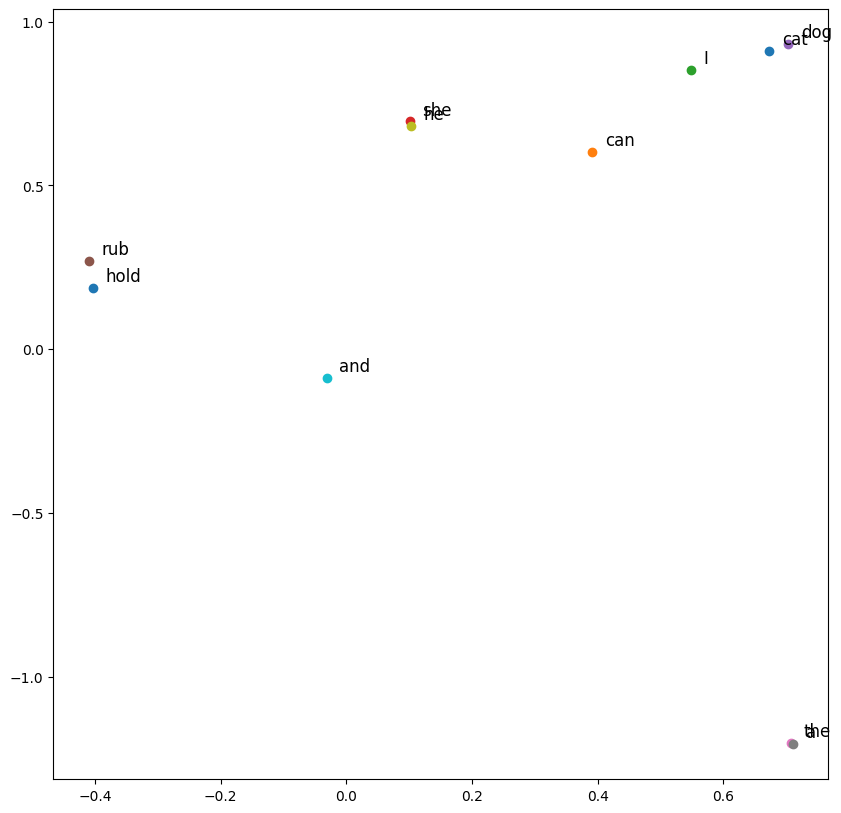

In [47]:
# Visualize the embeddings
import matplotlib.pyplot as plt

def plot_embeddings(model, i2v):
    embeddings = model.embedding.data.numpy()
    plt.figure(figsize=(10, 10))
    for i, word in i2v.items():
        x, y = embeddings[i]
        plt.scatter(x, y)
        plt.text(x + 0.02, y + 0.02, word, fontsize=12)
    plt.show()

plot_embeddings(model, i2v)

---

**Your Turn**

* Look at the original corpus above. Do the results from the embedding make sense?  **The corpus is very small and repetitive, but the learned 2D embedding still captures some relationships:**
1. **dog and cat are close together because they appear in similar contexts.**
2. **rub and hold are close together because they are both actions applied to dogs/cats.**
3. **she and he are close together because they appear in similar grammatical positions.**
4. **the and a are close together because they are both articles.**
5. **and is separated because it plays a different connecting role.**

* What could happen when the window size is too large? **If the window size is too large, almost every word becomes a context word for every other word. Then the model loses local meaning. For example, instead of learning: dog appears near hold, rub, the, a; it may learn: dog appears near almost everything**

* At what value would window become too large for this corpus? **The corpus vocabulary has only 11 words, and each sentence is very short. So a window size around the length of a full sentence would be too large.**


---